# Gast-Solla-Kennedy model: two-population resting state on a full connectome

This demo simulates the **two-population (E-I) adaptive-Izhikevich mean-field
model** of Gast, Solla & Kennedy (2024, *PNAS* 121(22) e2311885121,
[doi:10.1073/pnas.2311885121](https://doi.org/10.1073/pnas.2311885121)) on a
whole-brain structural connectome, in its **resting / quiescent regime**.

Each region holds **two coupled neural masses**: a regular-spiking
**excitatory (RS)** population and a fast-spiking **inhibitory (FS)**
interneuron population. The model is the firing-rate reduction of all-to-all
coupled adaptive (Izhikevich) neurons with a Lorentzian distribution of spike
thresholds. Each mass has four state variables

| symbol | meaning |
|---|---|
| `r` / `r_i` | mean firing rate (kHz) |
| `v` / `v_i` | mean membrane potential (mV) |
| `u` / `u_i` | mean recovery / spike-frequency-adaptation current (pA) |
| `s` / `s_i` | synaptic gating variable, driven by the rate |

The RS variables carry no suffix; the FS variables carry an `_i`. The two
masses are coupled *within* every region through four synaptic channels of
strengths `J_rr`, `J_rf`, `J_fr`, `J_ff` with synaptic reversal potentials
`E_AMPA` (excitatory) and `E_GABA` (inhibitory).

The TVB implementation is `tvb.simulator.models.GastSollaKennedy`, whose
defaults are the regular-spiking RS column of Table 1, the fast-spiking FS
column of Table 2 and the coupling strengths of Table 4 of the paper.  The
companion notebook `reproduce_figure_Gast_2024_PNAS.ipynb` reproduces the
paper's Fig. 2: it shows that the width of the FS spike-threshold
distribution decides whether inhibition *preserves* or *overwrites* the
excitatory bifurcation structure (heterogeneous vs. homogeneous FS).  This
notebook instead places the full E-I model on the **76-region human
connectome** and looks at the low-activity resting state.

**Regime.** We start every region at (or very near) its quiescent fixed point
(`r = 0`, `v = -60 mV` for the RS mass; `r_i = 0`, `v_i = -55 mV` for the FS
mass) and drive them with small homogeneous external currents
(`I = 30 pA`, `I_i = 5 pA`). This keeps both mean firing rates at, or very
close to, zero -- the network is *at rest* rather than tonically firing; the
initial relaxation of `v`, `u` (and their FS counterparts) seen in section 3
settles onto that near-fixed-point state, and is not ongoing activity. A
short second run, started from a perturbed high-rate state, shows that this
resting state is a stable attractor; section 6 additionally computes the
rate-based functional connectivity of that perturbation transient. Section 7
then leaves the resting regime altogether: it sweeps the global coupling on
the numba backend in search of the regime whose rate-based FC best matches
the structural connectome.

### The scientific picture

In the paper, the width of the FS spike-threshold distribution $\Delta_i$
decides whether an inhibitory population preserves or overwrites the
bifurcation structure of an excitatory population (mapped out in the
companion notebook). By embedding the **coupled E-I model** in TVB, this demo
keeps that interaction local within every region: the FS mass sends
inhibition onto the RS mass, and the RS mass drives the FS mass, so each
region's *internal* dynamics already reflect the E-I balance from the paper,
while *between* regions the structural connectome couples the excitatory
rates.

Three clarifications before starting:

* **"Resting state" here is a dynamical statement, not an empirical one.** It
  means both populations sit at their quiescent fixed points (mean firing
  rates approximately 0). The simulation is deterministic, so it produces
  *silence*, not the fluctuating spontaneous activity measured with
  resting-state fMRI, and no comparison to empirical functional connectivity
  is attempted (see the limitations in the Summary).
* **Bistability is what makes the resting state interesting.** At the
  parameters used here the RS population lies inside the bistable fold region
  of its bifurcation diagram (companion notebook, panel A): rest is a genuine
  attractor, not the only available state. Section 5 probes that attractor
  with a perturbation.
* **This is the 2024 model, not TVB's other "Gast" family.** The models in
  `tvb.simulator.models.infinite_theta` (`GastSchmidtKnosche_SD` /
  `GastSchmidtKnosche_SF`, Gast, Schmidt & Knosche 2020) are Ott-Antonsen
  reductions of QIF/theta neurons; `GastSollaKennedy` is the reduction of
  **adaptive Izhikevich** neurons.

In [1]:
from tvb.simulator.lab import *
import matplotlib.pyplot as plt
import numpy

## 1. Structural connectivity and model

We use the default 76-region structural connectome shipped with TVB
(weights + conduction delays). Note that this checkout requires an explicit
`connectivity.Connectivity.from_file()` (the `load_default=True` form is not
valid here) followed by `configure()`.

### The model in brief

`GastSollaKennedy` is the exact firing-rate reduction of infinite, all-to-all
coupled populations of adaptive Izhikevich neurons with a Lorentzian
distribution of spike thresholds (the Lorentzian ansatz in the spirit of
Montbrio-Pazo-Roxin applied to the Izhikevich model; Gast, Schmidt & Knosche
2021; Gast, Solla & Kennedy 2024). TVB exposes *both* columns of the paper's
tables, plus the two-population coupling:

**RS (excitatory) population — Table 1**

| parameter | default | meaning |
|---|---|---|
| `C` | 100 pF | membrane capacitance |
| `k` | 0.7 | scale of the quadratic membrane nonlinearity |
| `v_r` | -60 mV | resting membrane potential |
| `v_theta` | -40 mV | centre of the spike-threshold Lorentzian |
| `Delta` | 0.5 mV | **heterogeneity** of the RS thresholds |
| `b` | -2 | recovery sensitivity to subthreshold voltage |
| `tau_u` | 33.33 ms | recovery time constant |
| `kappa` | 10 pA | spike-frequency adaptation strength |
| `tau_s` | 6 ms | synaptic time constant |
| `I` | 0 pA (30 pA here) | external homogeneous current |

**FS (inhibitory) population — Table 2**

| parameter | default | meaning |
|---|---|---|
| `C_i` | 20 pF | membrane capacitance (fast-spiking) |
| `k_i` | 1.0 | scale of the quadratic membrane nonlinearity |
| `v_r_i` | -55 mV | resting membrane potential |
| `v_theta_i` | -40 mV | centre of the spike-threshold Lorentzian |
| `Delta_i` | 2.0 mV | **heterogeneity** of the FS thresholds (paper's knob) |
| `b_i` | 0.025 | recovery sensitivity to subthreshold voltage |
| `tau_u_i` | 5 ms | recovery time constant (fast) |
| `kappa_i` | 0 pA | no spike-frequency adaptation |
| `tau_s_i` | 8 ms | synaptic time constant |
| `I_i` | 0 pA (5 pA here) | external homogeneous current |

**Two-population coupling — Table 4**

| parameter | default | meaning |
|---|---|---|
| `J_rr` | 16 | RS -> RS (AMPA) synaptic strength |
| `J_rf` | 16 | FS -> RS (GABA\ :sub:`A`) synaptic strength |
| `J_fr` | 4 | RS -> FS (AMPA) synaptic strength |
| `J_ff` | 4 | FS -> FS (GABA\ :sub:`A`) synaptic strength |
| `E_AMPA` | 0 mV | excitatory synaptic reversal potential |
| `E_GABA` | -65 mV | inhibitory synaptic reversal potential |

Units follow the paper: `r` in kHz, `v` in mV, `u` in pA.

In [2]:
# Full 76-region human structural connectome (default weights and conduction delays)
conn = connectivity.Connectivity.from_file()
conn.configure()
print("Regions        :", conn.number_of_regions)
print("Max delay (mm) :", conn.tract_lengths.max())

# Two-population adaptive-Izhikevich mean-field model (Gast, Solla & Kennedy
# 2024): RS column of Table 1 + FS column of Table 2 + Table 4 coupling.
# Small external currents place both populations close to their quiescent
# fixed points (mean firing rates effectively zero).
model = models.GastSollaKennedy(I=numpy.array([30.0]), I_i=numpy.array([5.0]))
# monitor all eight state variables so the figures can show r, v, u, s and their FS counterparts
model.variables_of_interest = ("r", "v", "u", "s", "r_i", "v_i", "u_i", "s_i")
print("Model          :", type(model).__name__)
print("State vars     :", model.state_variables)
print("Variables of interest (monitored):", model.variables_of_interest)

2026-10-01 14:39:55,551 - WARNING - tvb.basic.readers - File 'hemispheres' not found in ZIP.


Regions        : 76
Max delay (mm) : 153.48574
Model          : GastSollaKennedy
State vars     : ('r', 'v', 'u', 's', 'r_i', 'v_i', 'u_i', 's_i')
Variables of interest (monitored): ('r', 'v', 'u', 's', 'r_i', 'v_i', 'u_i', 's_i')


## 2. Helper: run the model on the full connectome

The longitudinal coupling is `coupling.Linear()` (the default). The model
exposes its RS firing rate `r` to the coupling term (`cvar = (r, v)`,
`cr = 1`, `cv = 0`), so the firing rate of a source region's RS mass enters
the membrane-potential equation of a target region's RS mass. Integration is
deterministic (Heun, `dt = 0.01 ms`); all eight state variables
(`variables_of_interest = (r, v, u, s, r_i, v_i, u_i, s_i)`) are sampled once
per 1 ms.

While all regions sit at `r` close to 0 this inter-regional input is
negligible - the resting run below effectively probes the *local* E-I
attractor under the connectome's (silent) embedding. The FS masses are not
driven between regions; each region's inhibition is entirely local.

In [3]:
def simulate(initial_rate, initial_v, initial_u, initial_fs_rate, initial_fs_v,
             initial_fs_u, sim_length=1000.0):
    """Run the two-population Gast-Solla-Kennedy mean field on the full connectome.

    The initial condition is homogeneous across regions and given by the
    per-region tuple ``(r, v, u, s, r_i, v_i, u_i, s_i)``: RS mean firing rate
    ``r`` (kHz), membrane potential ``v`` (mV), adaptation ``u`` (pA), gating
    ``s``; then the same four for the FS mass (``*_fs``).

    Returns the monitor time vector and the state-variable array with shape
    ``(time, 8, regions)``; the blocks along axis 1 follow
    ``model.variables_of_interest``.
    """
    x0 = numpy.array([initial_rate, initial_v, initial_u, 0.0,
                      initial_fs_rate, initial_fs_v, initial_fs_u, 0.0])
    ic = numpy.repeat(x0.reshape(8, 1, 1), conn.number_of_regions, axis=1)
    ic = ic.reshape((1, 8, conn.number_of_regions, 1))

    sim = simulator.Simulator(
        model=model,
        connectivity=conn,
        coupling=coupling.Linear(),
        integrator=integrators.HeunDeterministic(dt=0.01),
        monitors=(monitors.TemporalAverage(period=1.0),),
        initial_conditions=ic,
        simulation_length=sim_length,
    )
    sim.configure()

    (time, data), = sim.run()
    # data has shape (time, 8, regions, modes)
    return time, data[:, :, :, 0]


STATE_LABELS = ("$r$ (Hz)", "$v$ (mV)", "$u$ (pA)", "$s$ (-)",
                "$r_i$ (Hz)", "$v_i$ (mV)", "$u_i$ (pA)", "$s_i$ (-)")


def plot_state_figure(time, data, title, zoom=None, overlays=None, ics=None, with_psd=False):
    """Panel figure of the global-mean state variables (columns: r, v, u, s, r_i, v_i, u_i, s_i).

    ``data`` has shape ``(time, 8, regions)``; the rate columns (0 and 4) are
    plotted in Hz. Row 1 spans the full window; if ``zoom`` (ms) is given, row
    2 repeats the same panels over the first ``zoom`` ms; if ``with_psd`` is
    set, a final row shows the Welch PSD of each variable. Returns the figure.
    """
    from scipy.signal import welch

    series = [1e3 * data[:, i, :].mean(axis=1) for i in (0, 4)]
    for i in (1, 2, 3):
        series.insert(i, data[:, i, :].mean(axis=1))
    series.insert(5, data[:, 5, :].mean(axis=1))
    series.insert(6, data[:, 6, :].mean(axis=1))
    series.insert(7, data[:, 7, :].mean(axis=1))

    n_time_rows = 1 + (zoom is not None)
    nrow = n_time_rows + (1 if with_psd else 0)
    fig, axes = plt.subplots(nrow, 8, figsize=(30, 2.6 * nrow))
    for row in range(n_time_rows):
        n = len(time) if row == 0 else int(round(zoom)) + 1
        for col in range(8):
            ax = axes[row][col]
            t = time[:n]
            ax.plot(t, series[col][:n], color="k", lw=1.2)
            for fn in (overlays or {}).get(col, []):
                fn(ax, t)
            if ics is not None:
                val = ics[col] if col not in (0, 4) else 1e3 * ics[col]
                ax.plot([0.0], [val], marker="o", ms=6, mfc="none", color="crimson")
            ax.set_xlim(t[0], t[-1])
            ax.set_title(STATE_LABELS[col], fontsize=9)
            if col == 0:
                ax.set_ylabel(STATE_LABELS[col])
            if row < n_time_rows - 1:
                ax.tick_params(labelbottom=False)
    if with_psd:
        fs = 1000.0  # TemporalAverage samples once per ms
        for col in range(8):
            ax = axes[n_time_rows][col]
            freq, psd = welch(series[col], fs=fs, nperseg=128)
            ax.semilogy(freq[1:], psd[1:], color="k")
            ax.set_xlim(0.0, fs / 2.0)
            ax.set_title(STATE_LABELS[col], fontsize=9)
            if col == 0:
                ax.set_ylabel("PSD")
        axes[-1][0].set_xlabel("frequency (Hz)")
    else:
        axes[-1][0].set_xlabel("time (ms)")
    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return fig

## 3. Resting-state simulation

Start every region's RS mass at its quiescent fixed point (`r = 0`,
`v = -60 mV`, `u = 0`) and the FS mass likewise at `r_i = 0`, `v_i = -55 mV`,
`u_i = 0`. With `I = 30 pA`, `I_i = 5 pA` both populations stay at (or relax
to) an essentially zero firing-rate resting state, with the FS mass receiving
tonic inhibition onto the RS mass through `J_rf` and the RS mass driving the
FS mass through `J_fr`.

At `I = 30 pA` with `Delta = 0.5 mV`, the single-RS bifurcation diagram
(companion notebook, panel A) places the RS population inside the bistable
fold region; the quiescent fixed point is stable but coexists with a spiking
attractor. The expectation for this run is therefore persistence at (or fast
relaxation to) `r` at or below $10^{-3}$ kHz and `r_i` at or below a few
$10^{-3}$ kHz - and nothing oscillatory.

In [4]:
time, data = simulate(initial_rate=0.0, initial_v=-60.0, initial_u=0.0,
                      initial_fs_rate=0.0, initial_fs_v=-55.0, initial_fs_u=0.0,
                      sim_length=1000.0)
r  = data[:, 0, :]   # RS firing rate (kHz)
v  = data[:, 1, :];  u  = data[:, 2, :];  s  = data[:, 3, :]
ri = data[:, 4, :]   # FS firing rate (kHz)
vi = data[:, 5, :];  ui = data[:, 6, :];  si = data[:, 7, :]
print("monitored state shape :", data.shape)
def rstat(name, R, Vs, Us, Ss):
    print("%s: mean rate %.3e kHz (%.3e Hz) | max %.3e kHz" % (name, R.mean(), 1e3*R.mean(), R.max()))
    print("   v in (%.2f, %.2f) mV | u in (%.3f, %.3f) pA | s in (%.3e, %.3e)" %
          (Vs.min(), Vs.max(), Us.min(), Us.max(), Ss.min(), Ss.max()))
rstat("RS", r, v, u, s)
rstat("FS", ri, vi, ui, si)

2026-10-01 14:39:55,676 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


monitored state shape : (1000, 8, 76)
RS: mean rate 2.379e-04 kHz (2.379e-01 Hz) | max 2.467e-04 kHz
   v in (-59.86, -56.90) mV | u in (-6.109, -0.003) pA | s in (9.098e-08, 1.480e-03)
FS: mean rate 7.482e-04 kHz (7.482e-01 Hz) | max 7.518e-04 kHz
   v in (-54.90, -54.66) mV | u in (0.000, 0.008) pA | s in (1.235e-05, 6.014e-03)


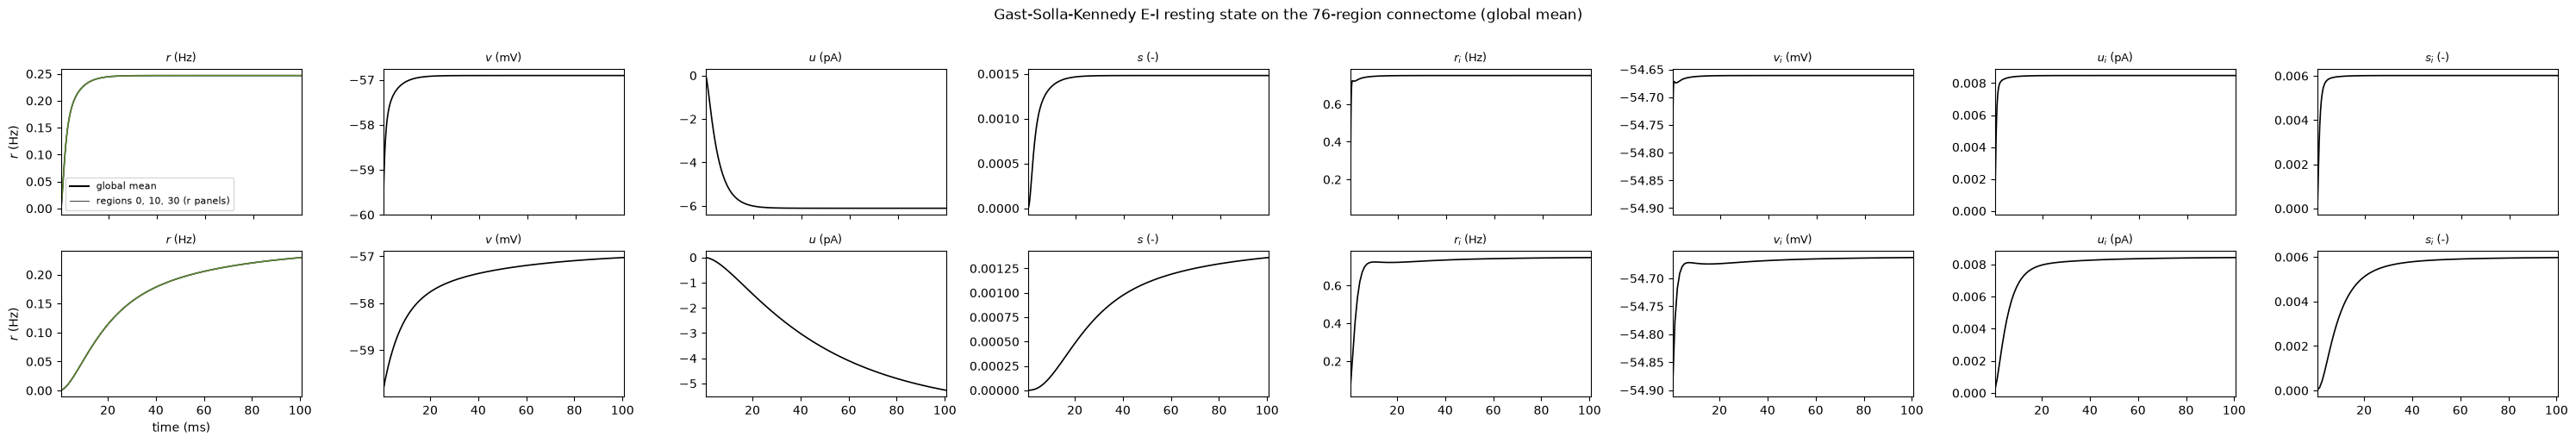

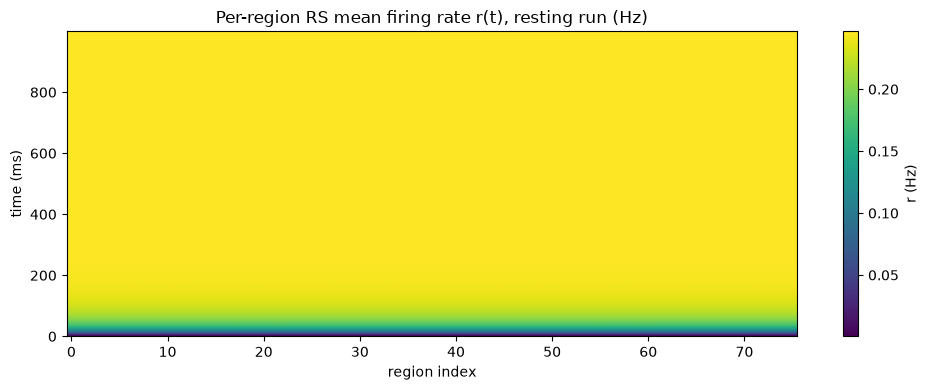

In [5]:
def region_traces(ax, t):
    """Per-region RS firing-rate traces, drawn on the r panel (column 0)."""
    for i in (0, 10, 30):
        ax.plot(t, 1e3 * r[:, i][: len(t)], lw=0.8, alpha=0.7)


fig = plot_state_figure(
    time,
    data,
    "Gast-Solla-Kennedy E-I resting state on the 76-region connectome (global mean)",
    zoom=100.0,
    overlays={0: [region_traces]},
)
import matplotlib.lines as mlines

fig.axes[0].legend(
    handles=[
        mlines.Line2D([], [], color="k", lw=1.5, label="global mean"),
        mlines.Line2D([], [], color="k", lw=0.8, alpha=0.7, label="regions 0, 10, 30 (r panels)"),
    ],
    fontsize=8,
    loc="best",
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(1e3 * r, aspect="auto", origin="lower", cmap="viridis")
ax.set_xlabel("region index")
ax.set_ylabel("time (ms)")
ax.set_title("Per-region RS mean firing rate r(t), resting run (Hz)")
fig.colorbar(ax.images[0], ax=ax, label="r (Hz)")
plt.tight_layout()
plt.show()

The measured mean RS rate over all 76 regions and the full 1000 ms is of
order $10^{-4}$ kHz (roughly $0.25$ Hz), and the maximum over regions and
time is of the same order: the RS population sits essentially at zero. The FS
mass sits at a slightly higher but still quiet sub-Hz level. Both populations
are at their quiescent fixed points at `I = 30 pA`, `I_i = 5 pA` - the small
non-zero rates are a property of those fixed points, not spiking activity.
The per-region traces are indistinguishable from the global mean on this
scale: with all rates close to zero the linear coupling contributes nothing,
so the regions neither desynchronise nor perturb one another.

The remaining panels show the rest of the E-I state space on the same time
base. Over roughly the first 100 ms - the zoomed second row - both driven
populations relax onto their quiescent fixed points: the RS rate rises
toward about 0.24 Hz, `v` from -60 to about -57 mV, `u` settles near -6 pA
and `s` near $1.5\cdot10^{-3}$; the FS mass relaxes to a quiet level
(`v_i` near -55 mV, `s_i` near $6\times10^{-3}$). After that all eight state
variables sit still; no panel exhibits oscillations or sustained activity,
and section 5 shows the same state is returned to after a perturbation.

## 4. Power spectrum of the resting-state activity

The figure pairs the RS time series of section 3 with its power spectrum.
The spectrum is a smooth, featureless power-law continuum: there is no
oscillatory peak, which is the useful sanity check (the roll-off at the top
of the band is the 1 ms averaging window of the monitor, not a resonance).

Because the trajectory is, after a short transient, a fixed point of a
deterministic system, the spectrum must be free of oscillatory peaks; any
broadband content above the numerical floor comes from the transient. A peak
would have flagged spurious limit-cycle dynamics (from discretisation or
coupling-induced instability) and would invalidate the quiescent reading of
section 3. The absence of peaks is thus a sanity check, not a finding - add
a stochastic integrator if fluctuating, "resting-state-like" activity is the
goal.

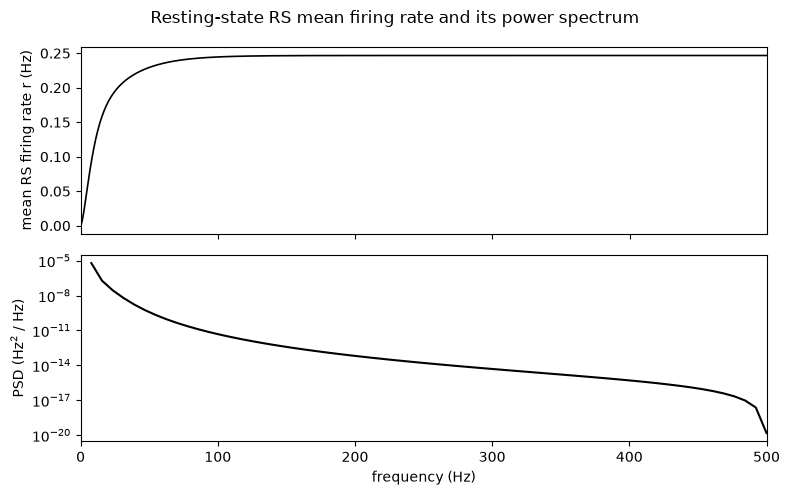

In [6]:
from scipy.signal import welch

fs = 1000.0  # TemporalAverage samples once per ms
r_mean = 1e3 * r.mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(8, 5))
axes[0].plot(time, r_mean, color="k", lw=1.2)
axes[0].set_xlim(time[0], time[-1])
axes[0].set_ylabel("mean RS firing rate r (Hz)")
axes[0].tick_params(labelbottom=False)
freq, psd = welch(r_mean, fs=fs, nperseg=128)
axes[1].semilogy(freq[1:], psd[1:], color="k")
axes[1].set_xlim(0.0, fs / 2.0)
axes[1].set_xlabel("frequency (Hz)")
axes[1].set_ylabel("PSD (Hz$^2$ / Hz)")
fig.suptitle("Resting-state RS mean firing rate and its power spectrum")
plt.tight_layout()
plt.show()

## 5. Relaxation back to rest from a perturbed state

To show that the quiescent resting state is a *stable* attractor, we restart
the same connectome from a perturbed high-rate state (RS `r = 0.05 kHz`,
`v = -45 mV`; FS `r_i = 0.05 kHz`, `v_i = -45 mV`) and watch the mean firing
rates decay back towards the resting levels.

Because the resting state is only *locally* stable - it coexists with a
spiking attractor - a small perturbation must decay back, whereas a
sufficiently large one could in principle carry the population across the
separatrix into spiking (the pulse-driven switching shown in panels C/D of
the companion reproduction). The perturbation used here turns out to be
sub-threshold: the panels below show all eight state variables decaying back
towards the resting levels of section 3 (dashed red line on the RS r panel),
with a final row of power spectra confirming that the relaxation is
non-oscillatory - local stability of the quiescent state in the connectome
setting.

2026-10-01 14:40:57,332 - WARNING - tvb.simulator.integrators - random_state supplied for non-stochastic integration


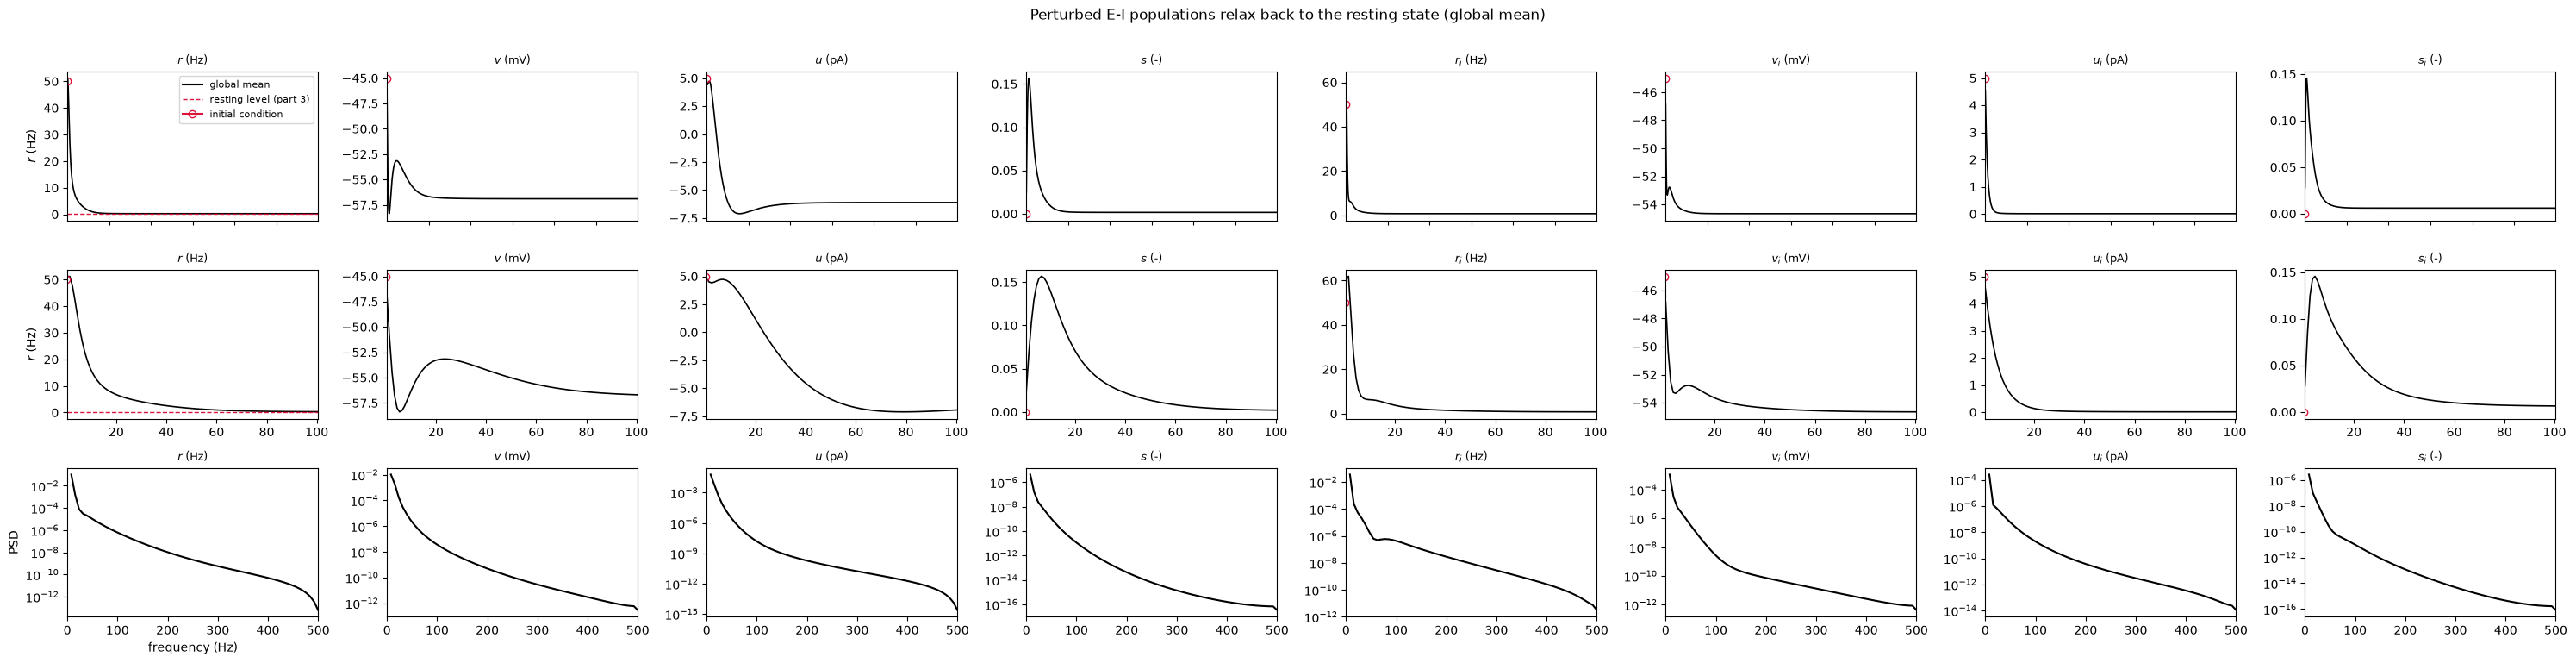

In [7]:
time_p, data_p = simulate(initial_rate=0.05, initial_v=-45.0, initial_u=5.0,
                          initial_fs_rate=0.05, initial_fs_v=-45.0, initial_fs_u=5.0,
                          sim_length=600.0)
r_p = data_p[:, 0, :]

rest_level = 1e3 * r.mean()


def rest_level_line(ax, t):
    """Dashed line at the resting-level mean RS rate of section 3."""
    ax.axhline(rest_level, color="crimson", ls="--", lw=1)


fig = plot_state_figure(
    time_p,
    data_p,
    "Perturbed E-I populations relax back to the resting state (global mean)",
    zoom=100.0,
    overlays={0: [rest_level_line]},
    ics=(0.05, -45.0, 5.0, 0.0, 0.05, -45.0, 5.0, 0.0),
    with_psd=True,
)
fig.axes[0].legend(
    handles=[
        mlines.Line2D([], [], color="k", lw=1.5, label="global mean"),
        mlines.Line2D([], [], color="crimson", ls="--", lw=1, label="resting level (part 3)"),
        mlines.Line2D([], [], marker="o", ms=6, mfc="none", color="crimson", label="initial condition"),
    ],
    fontsize=8,
    loc="best",
)
plt.show()

## 6. Functional connectivity of the relaxation transient

The resting run of section 3 has essentially zero variance in every region,
so a correlation-based functional connectivity (FC) is undefined there -
this is the same "deterministic silence" limitation noted in the Summary.
The perturbed run of section 5, however, contains real (albeit transient)
fluctuations, so a rate-based FC can be computed there: the Pearson
correlation of the per-region mean RS firing rates over the full 600 ms
window.

Because the initial condition is homogeneous and the transient is a
common-mode relaxation, all regions move nearly in lockstep; the expected
FC matrix is therefore close to one everywhere, with only a weak residual
that the linear coupling imprints through the structural row sums. The
structural connectivity matrix (weights, normalised) is shown for reference.

FC off-diagonal   : mean 1.0000, std 0.0000
residual amplitude: max |r - <r>| = 3.204e-06 kHz (peak r = 5.123e-02 kHz)
residual FC off-diagonal std : 0.9156


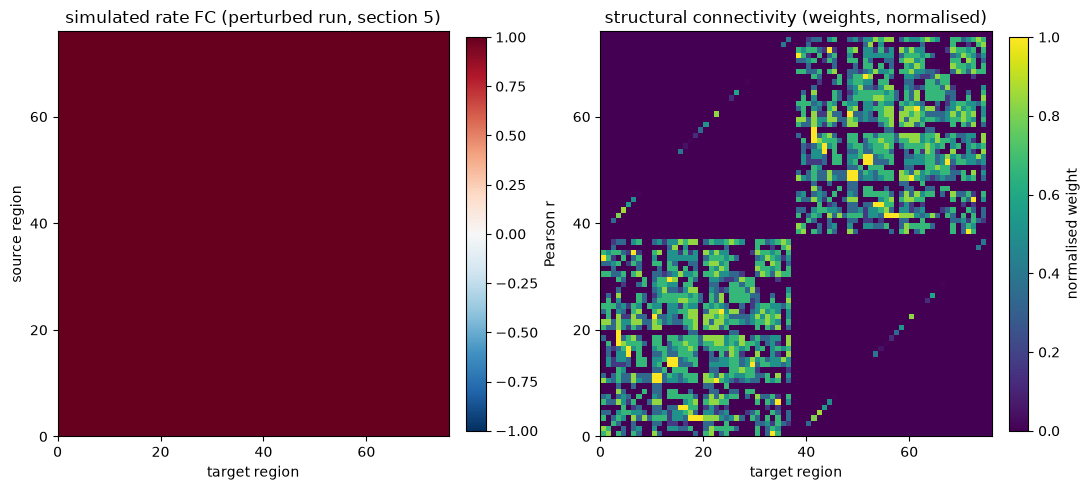

In [8]:
fc = numpy.corrcoef(r_p, rowvar=False)
rp_res = r_p - r_p.mean(axis=1, keepdims=True)
fc_res = numpy.corrcoef(rp_res, rowvar=False)
off = ~numpy.eye(fc.shape[0], dtype=bool)
print("FC off-diagonal   : mean %.4f, std %.4f" % (fc[off].mean(), fc[off].std()))
print("residual amplitude: max |r - <r>| = %.3e kHz (peak r = %.3e kHz)" % (numpy.abs(rp_res).max(), r_p.max()))
print("residual FC off-diagonal std : %.4f" % (fc_res[off].std()))

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = axes[0].pcolormesh(fc, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
axes[0].set_title("simulated rate FC (perturbed run, section 5)")
sc_n = 0.5 * (conn.weights + conn.weights.T)
im1 = axes[1].pcolormesh(sc_n / sc_n.max(), cmap="viridis", vmin=0.0, vmax=1.0)
axes[1].set_title("structural connectivity (weights, normalised)")
for ax in axes:
    ax.set_xticks(range(0, 76, 20))
    ax.set_yticks(range(0, 76, 20))
    ax.set_xlabel("target region")
axes[0].set_ylabel("source region")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Pearson r")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="normalised weight")
plt.tight_layout()
plt.show()

The printed diagnostics read as follows. The off-diagonal entries of the raw
FC matrix are essentially $1.0000$ to several decimals (std well below
$10^{-4}$): every pair of regions is essentially perfectly correlated,
because the transient is a *common-mode* relaxation - the homogeneous initial
condition makes all 76 regions decay in lockstep. The between-region residual
is tiny (well below $10^{-5}$ kHz, far below the peak rate): the trace of the
coupling imprint through the structural row sums, and of the integrator's
noise floor. The residual FC matrix shows no resolvable structure, i.e. this
deterministic transient carries no structured functional connectivity beyond
the trivial common mode. Obtaining a meaningful FC - let alone a comparison
with empirical resting-state FC - requires the stochastic fluctuations
discussed in the Summary.

## 7. Which coupling best reproduces the structure? A sweep on the numba backend

The deterministic resting state of sections 3-6 is silent, so its functional
connectivity is trivial (section 6): every region simply decays in lockstep.
A question with a real answer - *is there a global coupling for which the
simulated FC resembles the structural connectome (SC)?* - therefore needs
(i) ongoing fluctuations, i.e. a stochastic integrator, and (ii) many
simulations, one per coupling value.

The second part is what TVB's unified **sweep API** is for:
`NbHybridBackend.sweep` compiles a single numba kernel that integrates *all*
coupling values in one launch and returns a `SweepResult` holding the
per-value time series. The network is written in the hybrid API: one
`Subnetwork` wrapping the two-population `GastSollaKennedy` with a
`HeunStochastic` scheme, and one `IntraProjection` carrying the connectome
weights and tract lengths.

Two details of that mapping matter:

* `source_cvar=[0]` reads the RS firing rate `r` of the source region, and
  the projection deposits the weighted sum into coupling slot 0
  (`target_cvar=[0]`), which is the model's `Coupling_Term_r`. The model
  multiplies that slot by `cr = 1` and adds it to the RS membrane-potential
  equation - the same input that `coupling.Linear()` produced above.
* The swept parameter is `coupling_scale`, which the API resolves to the `a`
  attribute (the global coupling) of the projection's `Linear` function.

The noise dispersion `nsig` lives on the integrator rather than the coupling,
so it is not swept by the API; it is fixed here and probed separately in the
last cell of this section.

In [9]:
import scipy.sparse as sp
from tvb.simulator.backend.nb_hybrid import NbHybridBackend
from tvb.simulator.hybrid.coupling import Linear
from tvb.simulator.hybrid.intra_projection import IntraProjection
from tvb.simulator.hybrid.network import NetworkSet
from tvb.simulator.hybrid.subnetwork import Subnetwork
from tvb.simulator.integrators import HeunStochastic
from tvb.simulator.noise import Additive

DT_SWEEP = 0.01        # ms, the integration step used throughout this notebook
NSTEP_SWEEP = 50000    # 500 ms of simulated time per coupling value
NSIG = 1e-6            # white-noise dispersion (an analysis parameter, see below)
WARM_MS = 20           # transient discarded before the FC is measured
BLOCK = 100            # steps averaged into one 1 ms sample


def build_sweep_network(nsig=NSIG):
    """The 76-region connectome as a hybrid (numba) network set.

    A single subnetwork holds one two-population ``GastSollaKennedy`` node per
    region, driven by additive white noise (`nsig`) and coupled through the
    connectome by an ``IntraProjection`` reading the RS rate and writing to
    coupling slot 0 (``Coupling_Term_r``).
    """
    model = models.GastSollaKennedy(I=numpy.array([30.0]), I_i=numpy.array([5.0]))
    model.configure()

    noise = Additive(nsig=numpy.array([nsig]))
    noise.noise_seed = 42
    noise.random_stream = numpy.random.RandomState(42)
    noise.configure_white(DT_SWEEP)

    scheme = HeunStochastic(dt=DT_SWEEP, noise=noise)
    scheme.configure_boundaries(model)

    subnet = Subnetwork(name="ctx", model=model, scheme=scheme,
                        nnodes=conn.number_of_regions)
    subnet.projections = [
        IntraProjection(
            source_cvar=numpy.array([0], dtype=numpy.int_),  # source: RS rate r
            target_cvar=numpy.array([0], dtype=numpy.int_),  # slot 0: Coupling_Term_r
            weights=sp.csr_matrix(conn.weights.astype(numpy.float32)),
            lengths=sp.csr_matrix(conn.tract_lengths.astype(numpy.float32)),
            cv=float(conn.speed[0]),
            dt=DT_SWEEP,
            scale=1.0,
            cfun=Linear(a=numpy.array([1e-2])),   # a = global coupling (swept)
        )
    ]
    subnet.configure()
    network = NetworkSet(subnets=[subnet], projections=[])
    network.configure()
    return network


sweep_network = build_sweep_network()
# the quiescent fixed point of section 3 (end-state, region-averaged) as IC
rest_end = data[-1, :, :].mean(axis=1)
sweep_state0 = numpy.tile(
    rest_end.astype(numpy.float32).reshape(8, 1, 1),
    (1, conn.number_of_regions, 1),
)
print("subnetworks    :", [sn.name for sn in sweep_network.subnets])
print("state shape    :", sweep_state0.shape, "(variables, regions, modes)")
print("resting end-state (r, v, u, s, r_i, v_i, u_i, s_i) =",
      numpy.round(rest_end, 4))
print("max delay (ms) : %.1f" % (conn.tract_lengths.max() / conn.speed[0]))
print("noise sigma    :", NSIG)

subnetworks    : ['ctx']
state shape    : (8, 76, 1) (variables, regions, modes)
resting end-state (r, v, u, s, r_i, v_i, u_i, s_i) = [ 2.00000e-04 -5.69044e+01 -6.10890e+00  1.50000e-03  8.00000e-04
 -5.46610e+01  8.50000e-03  6.00000e-03]
max delay (ms) : 51.2
noise sigma    : 1e-06


/home/duke/src/tvb-hybrid/tvb_library/tvb/simulator/hybrid/__init__.py:165: UserWarning: Hybrid simulation is experimental: please report bugs or suggestions.
  warnings.warn(msg)


### Running the sweep

Each coupling value is repeated three times: the sweep draws an independent
noise realisation for every row, so the repeats give us error bars on the FC
- SC match rather than a single noisy number.

In [10]:
import time

backend = NbHybridBackend()
grid = numpy.array([5.0, 14.0, 30.0, 50.0, 90.0], dtype=numpy.float32)
repeats = 3
couplings = numpy.repeat(grid, repeats)

t0 = time.perf_counter()
sweep = backend.sweep(
    sweep_network,
    params={"coupling_scale": couplings},   # resolves to the cfun's 'a'
    nstep=NSTEP_SWEEP,
    backend="cpu",
    monitor="tavg",
    initial_states=[sweep_state0],
)
print("backend        :", sweep.backend)
print("wall clock     : %.1f s (includes kernel compilation)" % (time.perf_counter() - t0))
print("tavg shape     :", sweep.merged_tavg.shape, "(sweeps, samples, voi, regions, modes)")
print("sample step    : %.2f ms" % (sweep.times[1] - sweep.times[0]))

backend        : cpu-seq
wall clock     : 107.8 s (includes kernel compilation)
tavg shape     : (15, 50000, 1, 76, 1) (sweeps, samples, voi, regions, modes)
sample step    : 0.01 ms


### Comparing the simulated FC with the structural connectome

The `tavg` monitor samples every integration step here, so we first average
it into 1 ms bins (matching the sampling used in the lab simulations), drop
the first `WARM_MS`, and then take the Pearson correlation across time
between every pair of regions. The agreement with the SC is measured as the
Pearson correlation of the off-diagonal entries of the two matrices.

mean rate (Hz) per coupling : [ 3.    3.14  4.76 18.23 31.46]
mean off-diagonal FC        : [0.002 0.001 0.087 0.635 0.724]
corr(FC, SC) per coupling   : [ 0.006 -0.01   0.138  0.244  0.226] +/- [0.01  0.01  0.06  0.007 0.016]
best coupling a = 50 (corr(FC, SC) = 0.244 +/- 0.007)


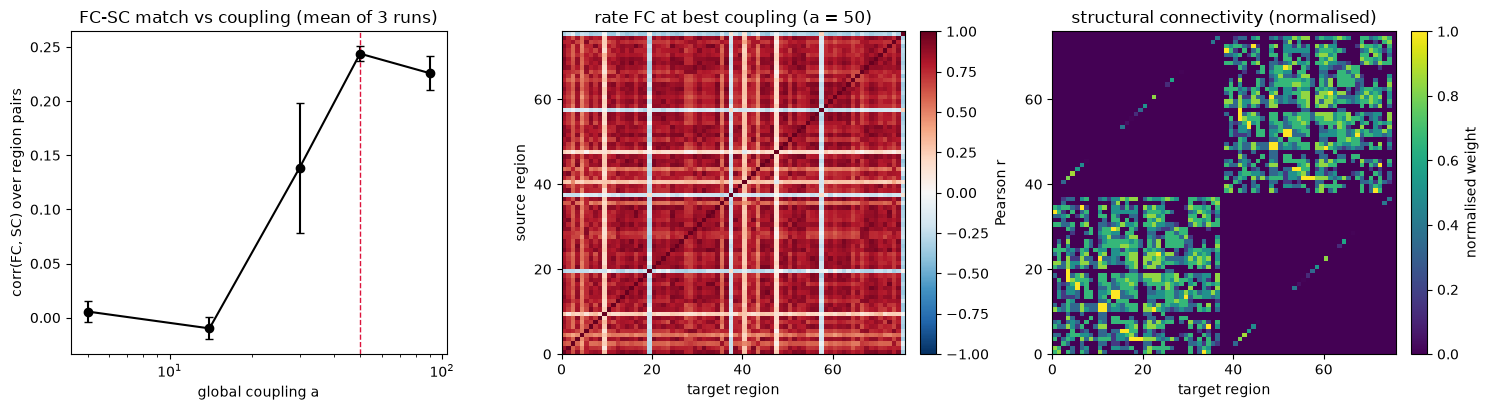

In [11]:
sc_sym = 0.5 * (conn.weights + conn.weights.T)
sc_norm = sc_sym / sc_sym.max()
upper = numpy.triu_indices(conn.number_of_regions, 1)

r_series = sweep.merged_tavg[:, :, 0, :, 0]          # (sweeps, samples, regions), RS rate
n_warm = int(round(WARM_MS / DT_SWEEP))
n_ms = (r_series.shape[1] - n_warm) // BLOCK
r_blocked = r_series[:, n_warm:n_warm + n_ms * BLOCK].reshape(
    len(couplings), n_ms, BLOCK, conn.number_of_regions).mean(axis=2)

fc_all = numpy.array([numpy.corrcoef(r, rowvar=False) for r in r_blocked])
match = numpy.array([numpy.corrcoef(fc[upper], sc_sym[upper])[0, 1] for fc in fc_all])
match_mean = numpy.array([match[numpy.isclose(couplings, a)].mean() for a in grid])
match_std = numpy.array([match[numpy.isclose(couplings, a)].std() for a in grid])
rate_mean = numpy.array([1e3 * r_blocked[numpy.isclose(couplings, a)].mean() for a in grid])
fc_off = numpy.array([fc[upper].mean() for fc in fc_all])

print("mean rate (Hz) per coupling :", numpy.round(rate_mean, 2))
print("mean off-diagonal FC        :", numpy.round([fc_off[numpy.isclose(couplings, a)].mean() for a in grid], 3))
print("corr(FC, SC) per coupling   :", numpy.round(match_mean, 3), "+/-", numpy.round(match_std, 3))
best = int(numpy.argmax(match_mean))
print("best coupling a = %.0f (corr(FC, SC) = %.3f +/- %.3f)"
      % (grid[best], match_mean[best], match_std[best]))

# the realisation closest to the mean match, so the matrix shown is typical
sel = numpy.isclose(couplings, grid[best])
rep = int(numpy.argmin(numpy.abs(match[sel] - match_mean[best])))
fc_best = fc_all[sel][rep]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].errorbar(grid, match_mean, yerr=match_std, fmt="o-", color="k", capsize=3)
axes[0].axvline(grid[best], color="crimson", ls="--", lw=1)
axes[0].set_xscale("log")
axes[0].set_xlabel("global coupling a")
axes[0].set_ylabel("corr(FC, SC) over region pairs")
axes[0].set_title("FC-SC match vs coupling (mean of %d runs)" % repeats)
im0 = axes[1].pcolormesh(fc_best, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
axes[1].set_title("rate FC at best coupling (a = %.0f)" % grid[best])
im1 = axes[2].pcolormesh(sc_norm, cmap="viridis", vmin=0.0, vmax=1.0)
axes[2].set_title("structural connectivity (normalised)")
for ax in axes[1:]:
    ax.set_xticks(range(0, 76, 20))
    ax.set_yticks(range(0, 76, 20))
    ax.set_xlabel("target region")
axes[1].set_ylabel("source region")
fig.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04, label="Pearson r")
fig.colorbar(im1, ax=axes[2], fraction=0.046, pad=0.04, label="normalised weight")
plt.tight_layout()
plt.show()

### How sensitive is that to the noise?

`NSIG` was fixed at `1e-6` for the sweep. Repeating the best-coupling run
with a weaker and a stronger dispersion shows that the SC imprint is not a
generic property of the fluctuating network: it appears only in a window of
noise levels.

nsig=1e-07  mean rate 0.98 Hz  corr(FC, SC) = 0.016


nsig=1e-06  mean rate 17.87 Hz  corr(FC, SC) = 0.285


nsig=1e-05  mean rate 28.04 Hz  corr(FC, SC) = 0.068


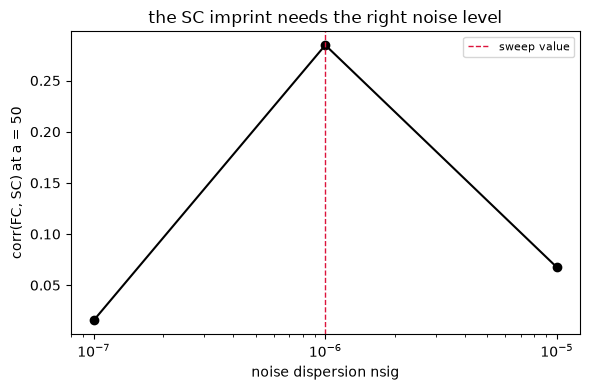

In [12]:
noise_levels = (1e-7, 1e-6, 1e-5)
noise_match = []
for nsig in noise_levels:
    res = backend.sweep(
        build_sweep_network(nsig),
        params={"coupling_scale": numpy.array([grid[best]], dtype=numpy.float32)},
        nstep=NSTEP_SWEEP,
        backend="cpu",
        monitor="tavg",
        initial_states=[sweep_state0],
    )
    r_n = res.merged_tavg[0, n_warm:n_warm + n_ms * BLOCK, 0, :, 0].reshape(
        n_ms, BLOCK, conn.number_of_regions).mean(axis=1)
    fc_n = numpy.corrcoef(r_n, rowvar=False)
    noise_match.append(numpy.corrcoef(fc_n[upper], sc_sym[upper])[0, 1])
    print("nsig=%.0e  mean rate %.2f Hz  corr(FC, SC) = %.3f"
          % (nsig, 1e3 * r_n.mean(), noise_match[-1]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogx(noise_levels, noise_match, "o-", color="k")
ax.axvline(NSIG, color="crimson", ls="--", lw=1, label="sweep value")
ax.set_xlabel("noise dispersion nsig")
ax.set_ylabel("corr(FC, SC) at a = %.0f" % grid[best])
ax.set_title("the SC imprint needs the right noise level")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### What the sweep says

* **Weak coupling: no imprint.** For `a <= 14` the match is near zero: the
  rate fluctuations are essentially independent per region, so the FC
  carries no SC structure even though the population is active.
* **Moderate coupling: the best regime.** The match is best at a moderate
  `a` and stays high over a window; at larger `a` the FC saturates towards
  global synchrony and the match decays again. Beyond the scan the
  mean-field equations can become numerically unstable, so the grid stops
  before that.
* **The right noise window.** At the best coupling, very weak noise leaves
  the match at zero (fluctuations too weak to couple the regions), an
  intermediate value gives a positive match, and stronger noise drops again
  (the white noise overrides the recurrent structure).

So the answer to the question is: **yes - a moderate global coupling
produces a rate-based FC that partially matches the SC, but only in an
active, partially synchronized regime and only for the right amount of
noise.** The agreement is modest (the SC explains only a small fraction of
the FC variance), and it is a statement about the model's regimes, not an
empirical claim about resting-state fMRI.

## Summary

* The two-population `GastSollaKennedy` mean-field model (RS excitatory + FS
  inhibitory; Gast, Solla & Kennedy 2024, PNAS) was simulated on the full
  76-region connectome with linear coupling and a deterministic Heun
  integrator.
* Starting at the quiescent fixed point with small external currents
  (`I = 30 pA`, `I_i = 5 pA`), both populations remain in a **resting /
  quiescent regime** (near-zero mean firing rates, featureless power
  spectrum).
* A perturbed initial condition relaxes back to that resting level, i.e. the
  quiescent state is a stable attractor of the network dynamics.
* The figures show all eight state variables (RS `r`, `v`, `u`, `s` and FS
  `r_i`, `v_i`, `u_i`, `s_i`) as time series (full window plus a zoomed 100 ms
  row, plus power spectra for the perturbed run) and a 76-region raster, so
  the (near-)silence of both masses is visible in the state space, not only
  in the rate.
* The rate-based functional connectivity of the perturbation transient is
  dominated by the common-mode relaxation (near-unity off-diagonals); the
  silent resting run has no fluctuations left to correlate.
* A sweep over the global coupling with the numba backend
  (`NbHybridBackend.sweep`, 76 regions, weak white noise, three independent
  noise realisations per value) shows that the SC imprint on the rate-based
  FC appears only at moderate coupling and the right noise level - the
  agreement requires an active, partially synchronized regime.

### Limitations and next steps

* **No fluctuations at rest.** With `HeunDeterministic` the resting state is
  a silent fixed point; the fluctuating, SC-structured regime of section 7
  required both a stochastic integrator (`HeunStochastic`) and a much
  stronger global coupling.
* **No BOLD / empirical link.** The section 6 FC is rate-based and computed
  from a deterministic transient; connecting to fMRI resting-state functional
  connectivity would require a BOLD monitor (and the stochastic fluctuations
  noted above) and a comparison to empirical FC - out of scope here.
* **Between-region coupling drives only the excitatory mass.** Inter-region
  input enters the RS membrane-potential equation (`cr = 1`); each region's
  inhibition is entirely local (FS fed by the local RS rate through
  `J_fr`/`J_ff`). Coupling the FS rates (or the membrane potentials `v`)
  between regions is a possible extension.
* **Mean-field assumptions.** The model is exact only for an infinite,
  all-to-all population with Lorentzian-distributed thresholds; each TVB
  region is treated as one E-I node.

See the companion demo `reproduce_figure_Gast_2024_PNAS.ipynb` for the
bifurcation structure and firing-rate panels of the original paper.